# Gold data lake, data analysis.

!aws s3 cp s3://storagestack-goldamzn20260353c3fe8c-aqocedbvmdqr/aggregations/ ./data/gold/ --recursive

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import glob
import json

GOLD = "data/gold/aggregations"
RUN_DATE = "2026-03-30"

def read_table(name):
    path = f"{GOLD}/{name}/run_date={RUN_DATE}/*.parquet"
    files = glob.glob(path)
    return pd.concat([pd.read_parquet(f) for f in files], ignore_index=True)

spend       = read_table("spend_by_age_band")
clients     = read_table("client_financial_activity")
channels    = read_table("channel_adoption")
provincial  = read_table("provincial_flow")
reversals   = read_table("reversal_rates")
time_of_day = read_table("time_of_day")
currency    = read_table("currency_by_age")
mcc         = read_table("mcc_spend")

print("Tables loaded:")
for name, df in [("spend_by_age_band", spend), ("client_financial_activity", clients),
                 ("channel_adoption", channels), ("provincial_flow", provincial),
                 ("reversal_rates", reversals), ("time_of_day", time_of_day),
                 ("currency_by_age", currency), ("mcc_spend", mcc)]:
    print(f"  {name}: {len(df):,} rows")

Tables loaded:
  spend_by_age_band: 36 rows
  client_financial_activity: 7,054 rows
  channel_adoption: 16 rows
  provincial_flow: 9 rows
  reversal_rates: 24 rows
  time_of_day: 144 rows
  currency_by_age: 41 rows
  mcc_spend: 11 rows


## 1. Spend by Age Band & Category

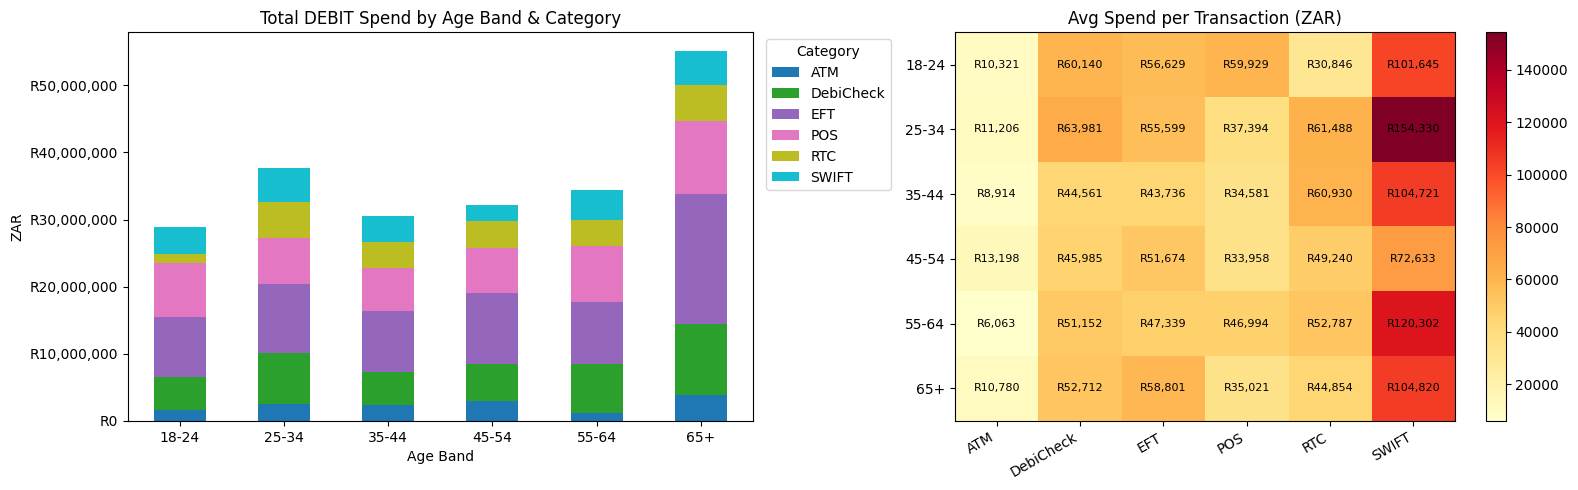

In [2]:
AGE_ORDER = ["18-24", "25-34", "35-44", "45-54", "55-64", "65+"]

pivot = (
    spend.pivot_table(index="age_band", columns="transaction_category",
                      values="total_spend", aggfunc="sum")
         .reindex(AGE_ORDER)
         .fillna(0)
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Stacked bar — total spend per age band
pivot.plot(kind="bar", stacked=True, ax=axes[0], colormap="tab10")
axes[0].set_title("Total DEBIT Spend by Age Band & Category")
axes[0].set_xlabel("Age Band")
axes[0].set_ylabel("ZAR")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"R{x:,.0f}"))
axes[0].tick_params(axis="x", rotation=0)
axes[0].legend(title="Category", bbox_to_anchor=(1.01, 1), loc="upper left")

# Heatmap — avg spend
avg_pivot = (
    spend.pivot_table(index="age_band", columns="transaction_category",
                      values="avg_spend", aggfunc="mean")
         .reindex(AGE_ORDER)
         .fillna(0)
)
im = axes[1].imshow(avg_pivot.values, aspect="auto", cmap="YlOrRd")
axes[1].set_xticks(range(len(avg_pivot.columns)))
axes[1].set_xticklabels(avg_pivot.columns, rotation=30, ha="right")
axes[1].set_yticks(range(len(avg_pivot.index)))
axes[1].set_yticklabels(avg_pivot.index)
axes[1].set_title("Avg Spend per Transaction (ZAR)")
for i in range(len(avg_pivot.index)):
    for j in range(len(avg_pivot.columns)):
        axes[1].text(j, i, f"R{avg_pivot.values[i, j]:,.0f}",
                     ha="center", va="center", fontsize=8)
plt.colorbar(im, ax=axes[1])

plt.tight_layout()
plt.show()

## 2. Channel Adoption

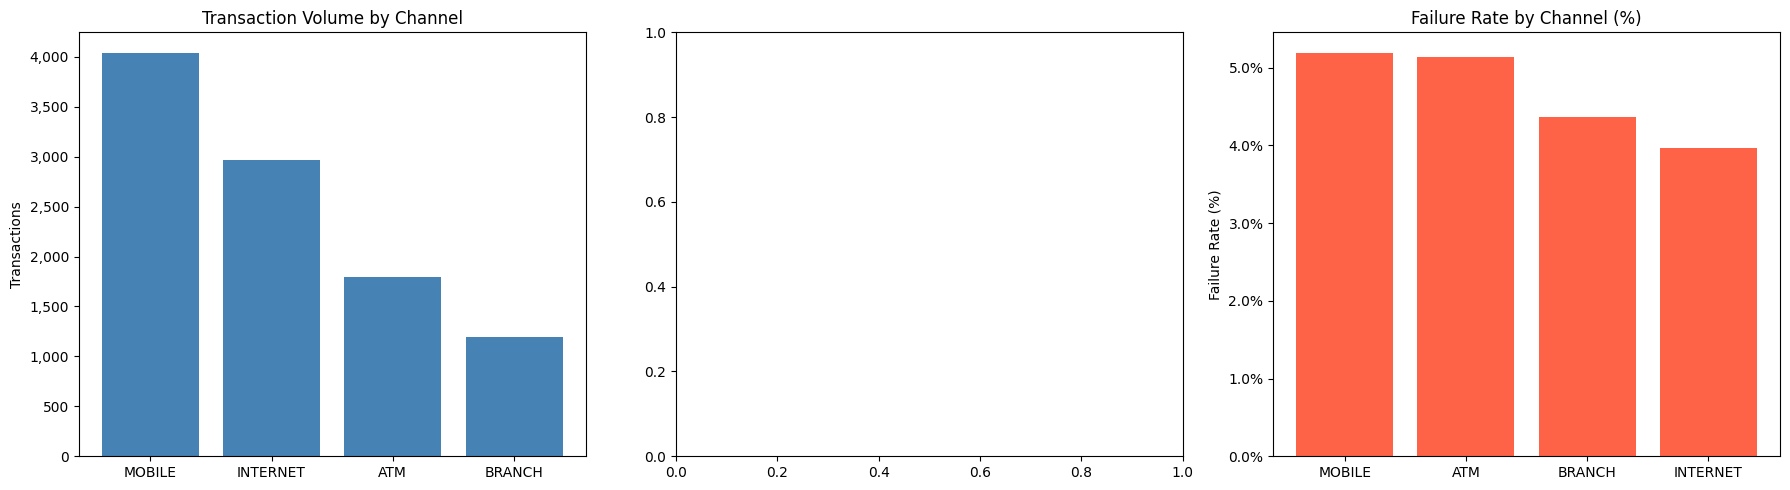

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Transaction volume by channel
vol = channels.groupby("channel")["total_transactions"].sum().sort_values(ascending=False)
axes[0].bar(vol.index, vol.values, color="steelblue")
axes[0].set_title("Transaction Volume by Channel")
axes[0].set_ylabel("Transactions")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))

# Failure rate by channel
fail = channels.groupby("channel").apply(
    lambda g: g["failed_count"].sum() / g["total_transactions"].sum()
).sort_values(ascending=False)
axes[2].bar(fail.index, fail.values * 100, color="tomato")
axes[2].set_title("Failure Rate by Channel (%)")
axes[2].set_ylabel("Failure Rate (%)")
axes[2].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.1f}%"))

plt.tight_layout()
plt.show()

## 3. Client Financial Activity

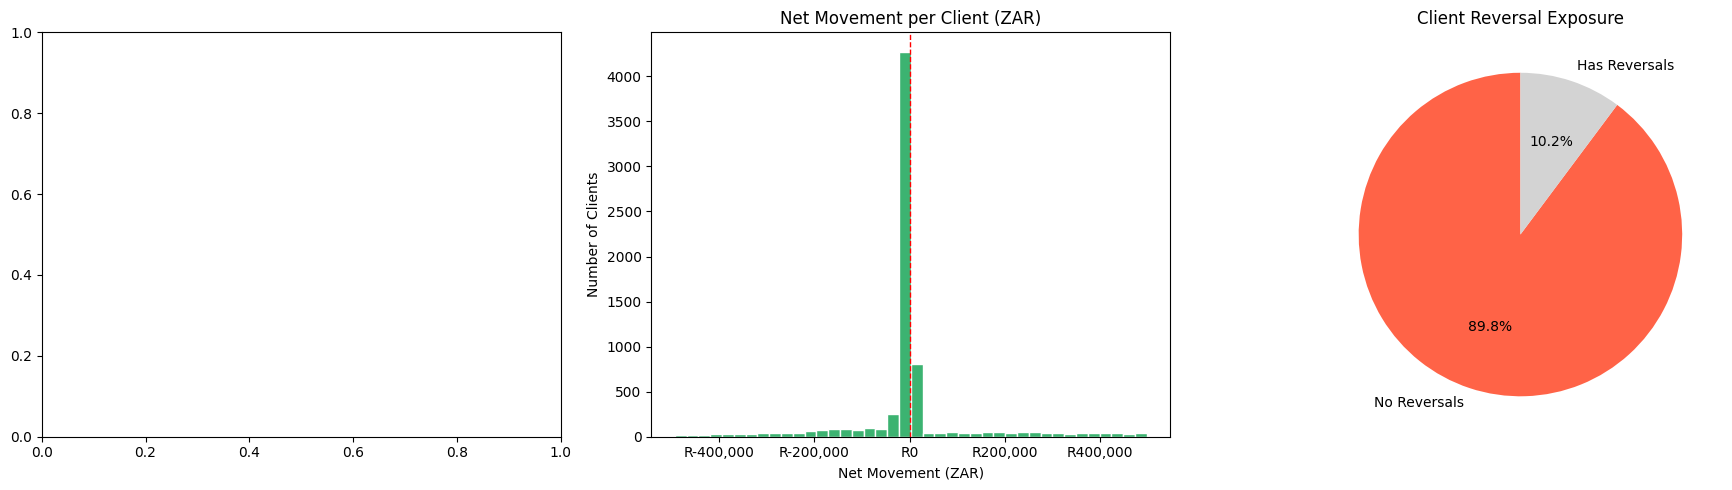


Client summary:
  Total clients          : 7,054
  Avg transactions/client: 1.0
  Median net movement    : R0.00
  Clients with reversals : 720


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Net movement distribution (positive = net credit, negative = net debit)
axes[1].hist(clients["net_movement"], bins=40, color="mediumseagreen", edgecolor="white")
axes[1].axvline(0, color="red", linestyle="--", linewidth=1)
axes[1].set_title("Net Movement per Client (ZAR)")
axes[1].set_xlabel("Net Movement (ZAR)")
axes[1].set_ylabel("Number of Clients")
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"R{x:,.0f}"))

# Reversal exposure: clients with 0 vs 1+ reversals
rev_flag = clients["reversal_count"].apply(lambda x: "Has Reversals" if x > 0 else "No Reversals")
rev_counts = rev_flag.value_counts()
axes[2].pie(rev_counts, labels=rev_counts.index, autopct="%1.1f%%",
            colors=["tomato", "lightgrey"], startangle=90)
axes[2].set_title("Client Reversal Exposure")

plt.tight_layout()
plt.show()

print(f"\nClient summary:")
print(f"  Total clients          : {len(clients):,}")
print(f"  Avg transactions/client: {clients['total_transactions'].mean():.1f}")
print(f"  Median net movement    : R{clients['net_movement'].median():,.2f}")
print(f"  Clients with reversals : {(clients['reversal_count'] > 0).sum():,}")

## 4. Reversal & Failure Rates by Category

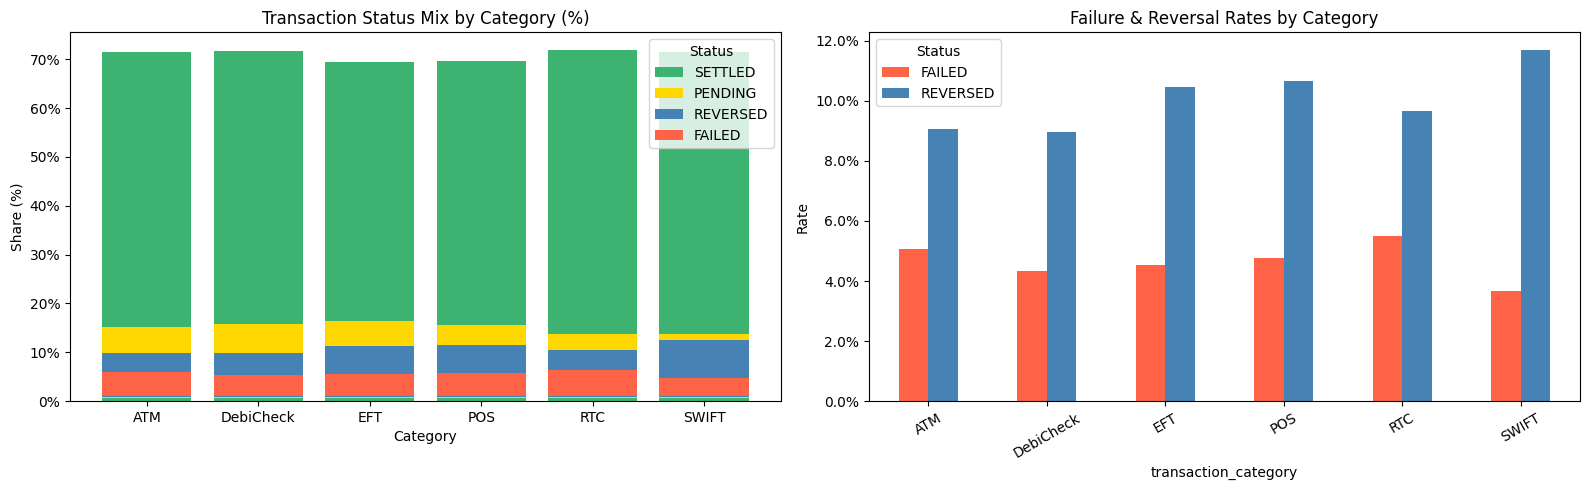

In [5]:
STATUS_ORDER = ["SETTLED", "PENDING", "REVERSED", "FAILED"]
STATUS_COLORS = {"SETTLED": "mediumseagreen", "PENDING": "gold",
                 "REVERSED": "steelblue", "FAILED": "tomato"}

pivot_r = (
    reversals.pivot_table(index="transaction_category", columns="status",
                          values="rate", aggfunc="sum")
             .reindex(columns=STATUS_ORDER)
             .fillna(0)
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Stacked bar — status share per category
bottom = None
for status in STATUS_ORDER:
    if status not in pivot_r.columns:
        continue
    vals = pivot_r[status].values
    axes[0].bar(pivot_r.index, vals * 100,
                bottom=bottom if bottom is not None else 0,
                label=status, color=STATUS_COLORS[status])
    bottom = vals if bottom is None else bottom + vals

axes[0].set_title("Transaction Status Mix by Category (%)")
axes[0].set_ylabel("Share (%)")
axes[0].set_xlabel("Category")
axes[0].legend(title="Status")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}%"))

# Failure + reversal rates only
bad = reversals[reversals["status"].isin(["FAILED", "REVERSED"])].copy()
bad_pivot = bad.pivot_table(index="transaction_category", columns="status",
                             values="rate", aggfunc="sum").fillna(0)
bad_pivot.plot(kind="bar", ax=axes[1],
               color=[STATUS_COLORS.get(c, "grey") for c in bad_pivot.columns])
axes[1].set_title("Failure & Reversal Rates by Category")
axes[1].set_ylabel("Rate")
axes[1].tick_params(axis="x", rotation=30)
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x*100:.1f}%"))
axes[1].legend(title="Status")

plt.tight_layout()
plt.show()

## 5. Time-of-Day Spending Patterns

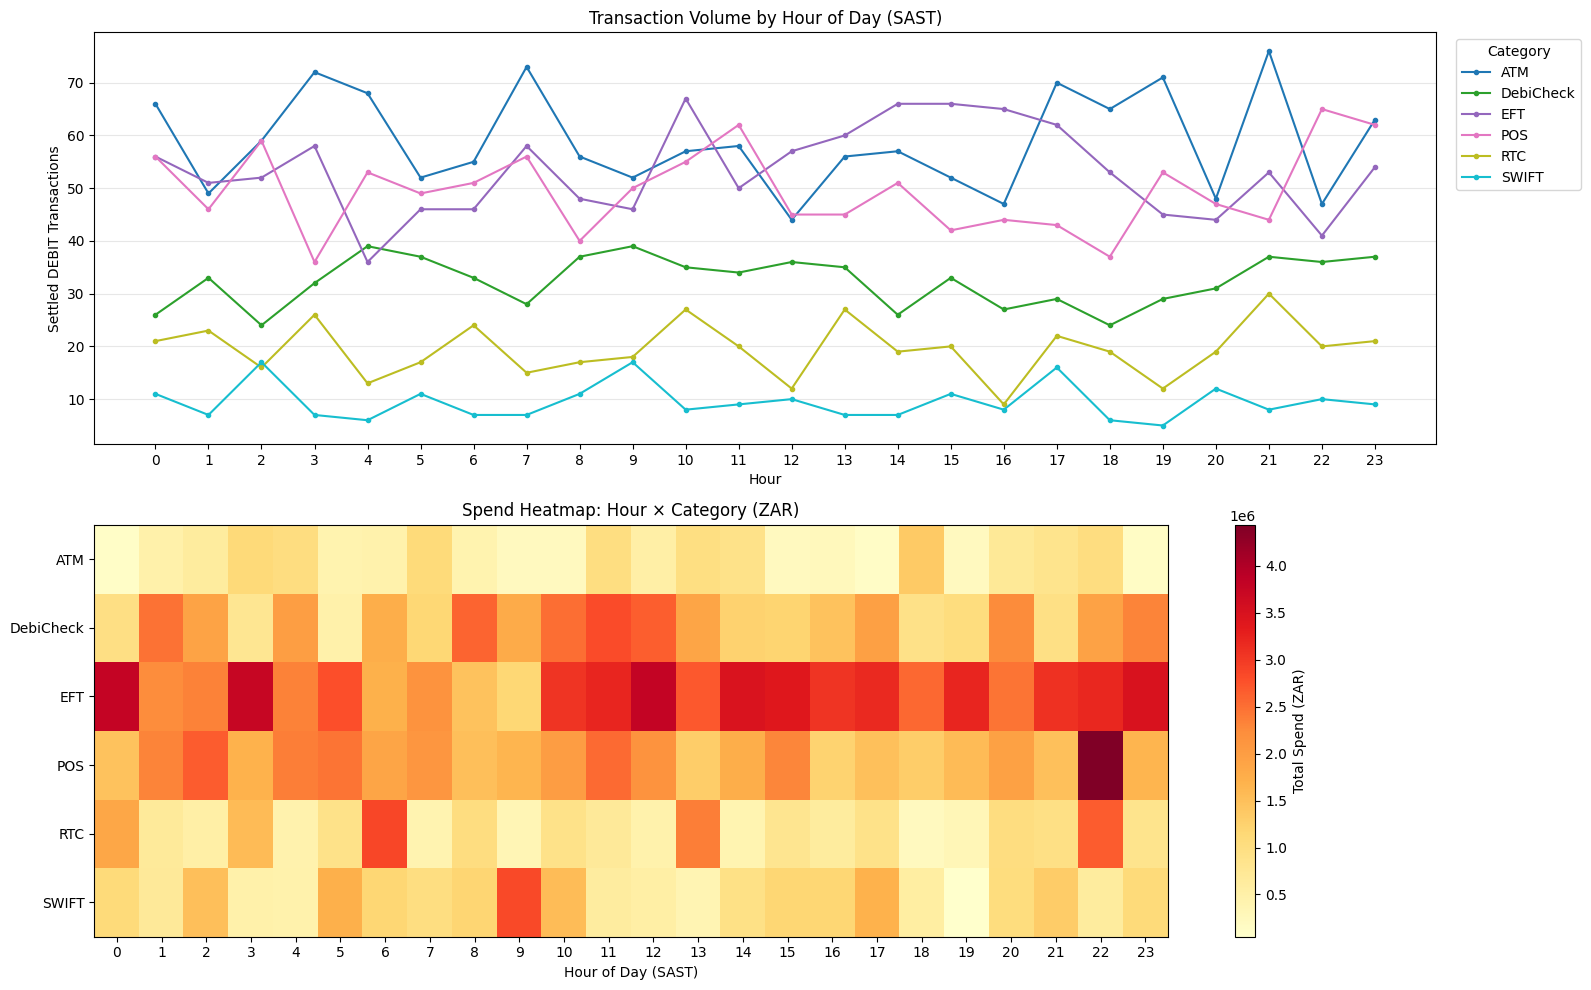

In [6]:
tod_pivot = (
    time_of_day.pivot_table(index="hour_of_day", columns="transaction_category",
                             values="transaction_count", aggfunc="sum")
               .reindex(range(24))
               .fillna(0)
)

fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# Line chart — transaction count by hour
tod_pivot.plot(ax=axes[0], colormap="tab10", marker="o", markersize=3)
axes[0].set_title("Transaction Volume by Hour of Day (SAST)")
axes[0].set_xlabel("Hour")
axes[0].set_ylabel("Settled DEBIT Transactions")
axes[0].set_xticks(range(24))
axes[0].legend(title="Category", bbox_to_anchor=(1.01, 1), loc="upper left")
axes[0].grid(axis="y", alpha=0.3)

# Heatmap — total spend by hour and category
spend_pivot = (
    time_of_day.pivot_table(index="hour_of_day", columns="transaction_category",
                             values="total_spend", aggfunc="sum")
               .reindex(range(24))
               .fillna(0)
)
im = axes[1].imshow(spend_pivot.values.T, aspect="auto", cmap="YlOrRd")
axes[1].set_yticks(range(len(spend_pivot.columns)))
axes[1].set_yticklabels(spend_pivot.columns)
axes[1].set_xticks(range(24))
axes[1].set_xticklabels(range(24))
axes[1].set_title("Spend Heatmap: Hour × Category (ZAR)")
axes[1].set_xlabel("Hour of Day (SAST)")
plt.colorbar(im, ax=axes[1], label="Total Spend (ZAR)")

plt.tight_layout()
plt.show()

## 6. Provincial ATM Flow

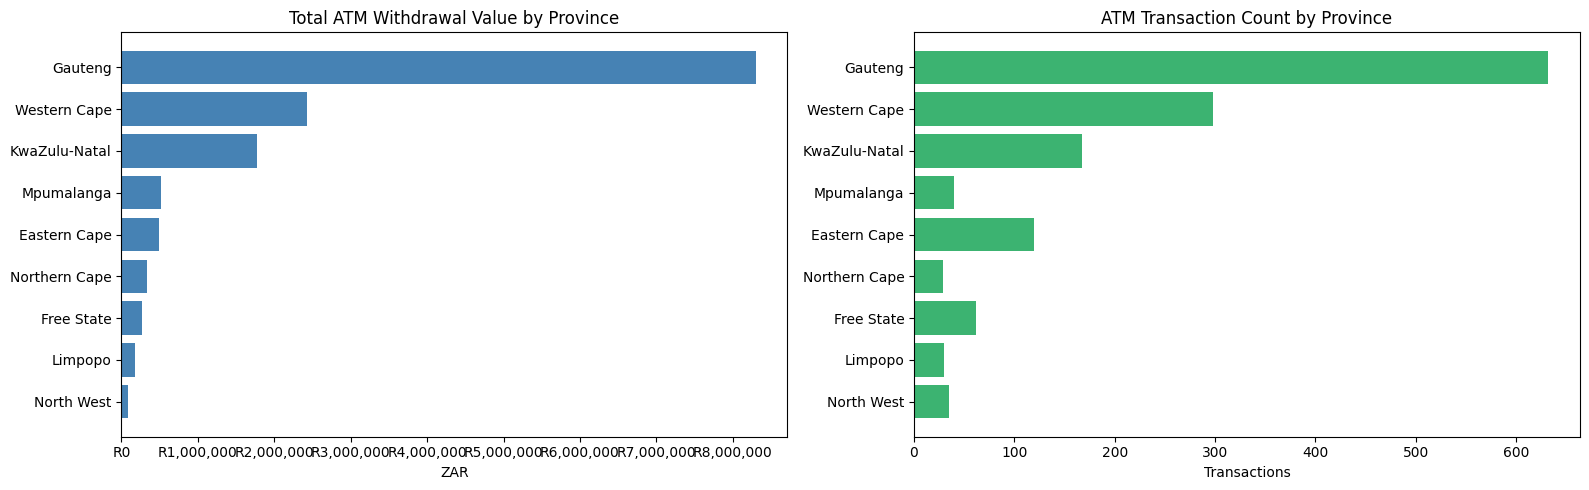

In [7]:
prov = provincial.sort_values("total_amount", ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Total ATM withdrawals by province
axes[0].barh(prov["atm_province"], prov["total_amount"], color="steelblue")
axes[0].set_title("Total ATM Withdrawal Value by Province")
axes[0].set_xlabel("ZAR")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"R{x:,.0f}"))

# Transaction count by province
axes[1].barh(prov["atm_province"], prov["transaction_count"], color="mediumseagreen")
axes[1].set_title("ATM Transaction Count by Province")
axes[1].set_xlabel("Transactions")
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))

plt.tight_layout()
plt.show()

## 7. MCC Spend Concentration

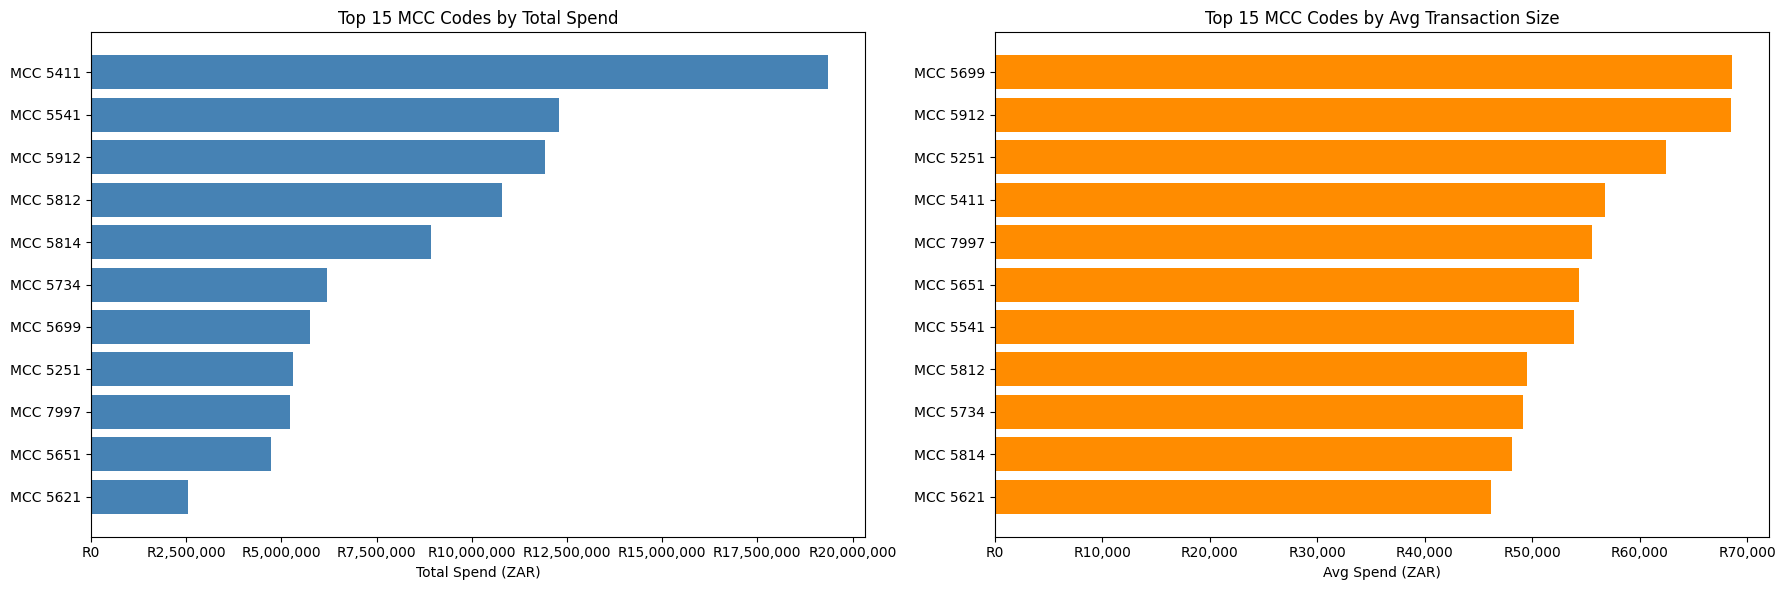

In [8]:
top_mcc = mcc.sort_values("total_spend", ascending=False).head(15)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Top MCC by total spend
axes[0].barh(top_mcc["merchant_category_code"][::-1],
             top_mcc["total_spend"][::-1], color="steelblue")
axes[0].set_title("Top 15 MCC Codes by Total Spend")
axes[0].set_xlabel("Total Spend (ZAR)")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"R{x:,.0f}"))

# Avg spend per transaction by MCC
avg_sorted = mcc.sort_values("avg_spend", ascending=False).head(15)
axes[1].barh(avg_sorted["merchant_category_code"][::-1],
             avg_sorted["avg_spend"][::-1], color="darkorange")
axes[1].set_title("Top 15 MCC Codes by Avg Transaction Size")
axes[1].set_xlabel("Avg Spend (ZAR)")
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"R{x:,.0f}"))

plt.tight_layout()
plt.show()

## 8. Currency Diversification by Age Band (SWIFT)

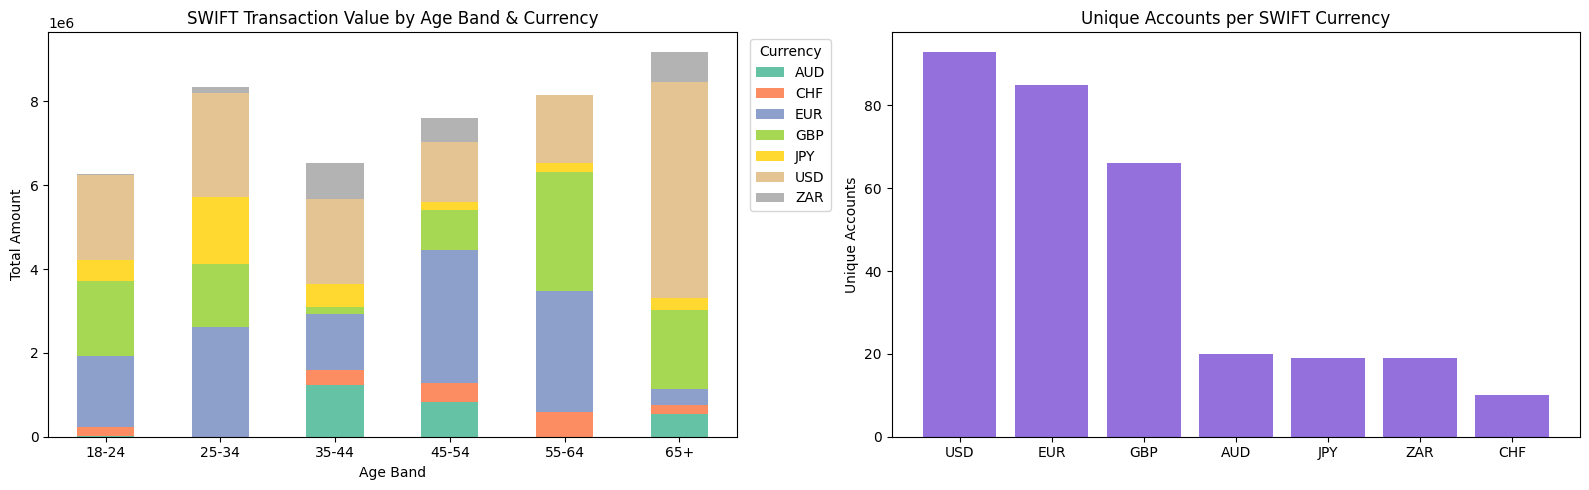

In [9]:
curr_pivot = (
    currency.pivot_table(index="age_band", columns="currency",
                         values="total_amount", aggfunc="sum")
            .reindex(AGE_ORDER)
            .fillna(0)
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

curr_pivot.plot(kind="bar", stacked=True, ax=axes[0], colormap="Set2")
axes[0].set_title("SWIFT Transaction Value by Age Band & Currency")
axes[0].set_xlabel("Age Band")
axes[0].set_ylabel("Total Amount")
axes[0].tick_params(axis="x", rotation=0)
axes[0].legend(title="Currency", bbox_to_anchor=(1.01, 1), loc="upper left")

# Count of unique SWIFT accounts by currency
acc = currency.groupby("currency")["unique_accounts"].sum().sort_values(ascending=False)
axes[1].bar(acc.index, acc.values, color="mediumpurple")
axes[1].set_title("Unique Accounts per SWIFT Currency")
axes[1].set_ylabel("Unique Accounts")

plt.tight_layout()
plt.show()

## 9. Silver Validation Report

Run date   : 2026-03-30
Rows       : 10,000
Passed     : 48/48
Overall    : PASS


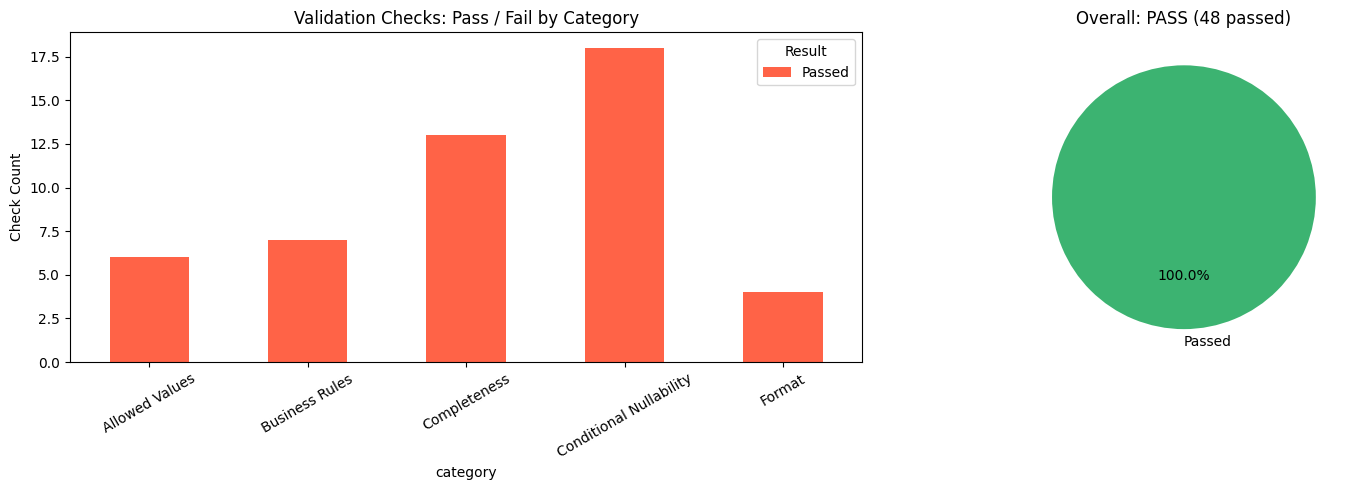


All checks passed.


In [10]:
report_path = f"data/gold/validation-analysis/year=2026/month=03/day=30/silver_validation.json"
with open(report_path) as f:
    report = json.load(f)

print(f"Run date   : {report['run_date']}")
print(f"Rows       : {report['total_rows']:,}")
print(f"Passed     : {report['checks_passed']}/{report['checks_passed'] + report['checks_failed']}")
print(f"Overall    : {report['overall']}")

checks_df = pd.DataFrame(report["results"])

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Pass/fail summary by category
summary = checks_df.groupby(["category", "passed"]).size().unstack(fill_value=0)
summary.columns = ["Failed", "Passed"] if False in summary.columns else ["Passed"]
summary.plot(kind="bar", ax=axes[0], color=["tomato", "mediumseagreen"])
axes[0].set_title("Validation Checks: Pass / Fail by Category")
axes[0].set_ylabel("Check Count")
axes[0].tick_params(axis="x", rotation=30)
axes[0].legend(title="Result")

# Overall pie
overall_counts = checks_df["passed"].value_counts()
labels = ["Passed" if v else "Failed" for v in overall_counts.index]
axes[1].pie(overall_counts, labels=labels, autopct="%1.1f%%",
            colors=["mediumseagreen", "tomato"], startangle=90)
axes[1].set_title(f"Overall: {report['overall']} ({report['checks_passed']} passed)")

plt.tight_layout()
plt.show()

failed = checks_df[~checks_df["passed"]]
if not failed.empty:
    print("\nFailed checks:")
    print(failed[["category", "check", "detail"]].to_string(index=False))
else:
    print("\nAll checks passed.")